# Linear regression showdown

## Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
import seaborn as sns

from src.models.logistic_regression import LogisticRegression as MlFunLogisticRegression

import pathlib

## Load data into Dataframe

In [2]:
BASE_DIR = pathlib.Path(".").resolve()
REGRESSION_PATH = BASE_DIR / "data" / "weatherAUS.csv"

In [3]:
df = pd.read_csv(REGRESSION_PATH, true_values=["Yes"], false_values=["No"])
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,False,False
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,False,False
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,False,False
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,False,False
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,False,False


## Select sample

This dataset is very big, over 14 000 records.
Because of that, we are going to take only 1000 records to increase the speed of training.

In [4]:
df = df.sample(n=1000, random_state=42)

## Convert target column to numeric

In [5]:
df = df.dropna()
df["RainTomorrow"] = df["RainTomorrow"].astype("int")

## Drop non-numeric tables

In [6]:
df = df.select_dtypes(include="number")

## Explore the dataset

### Visualise data

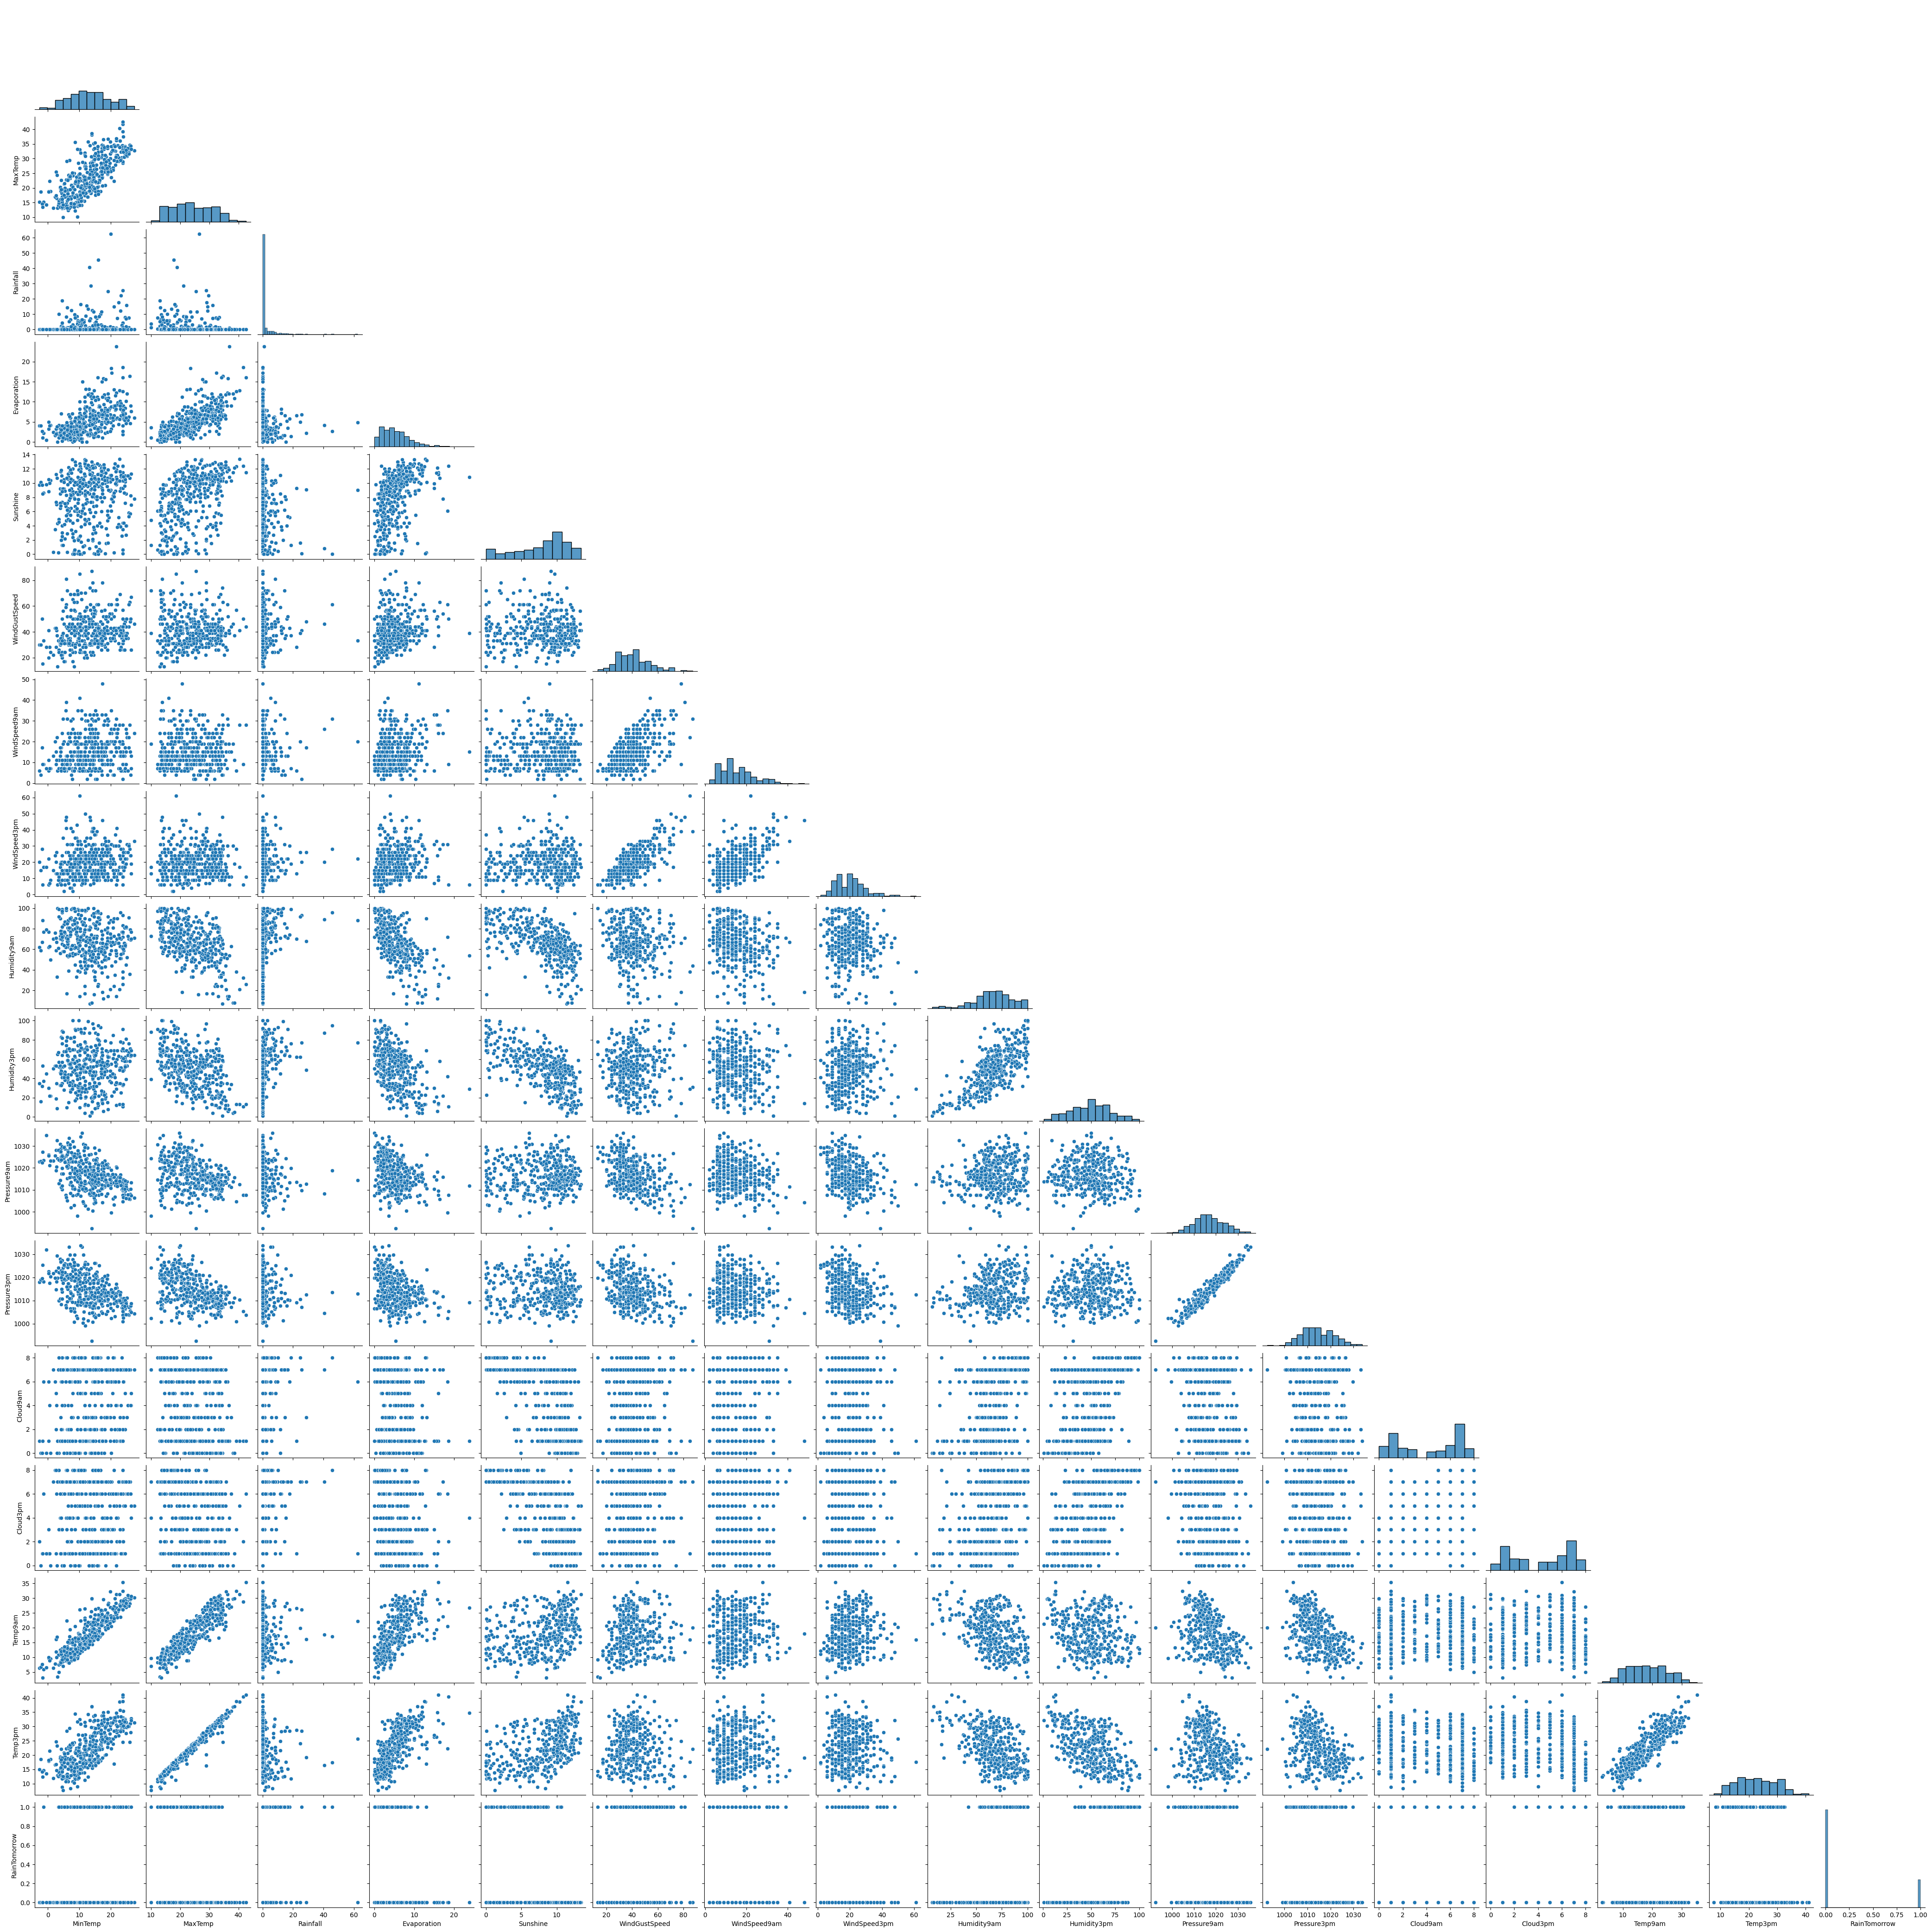

In [7]:
# Attention! This cell might take a second!
sns.pairplot(data=df, corner=True)

### Correlation heatmap

<Axes: >

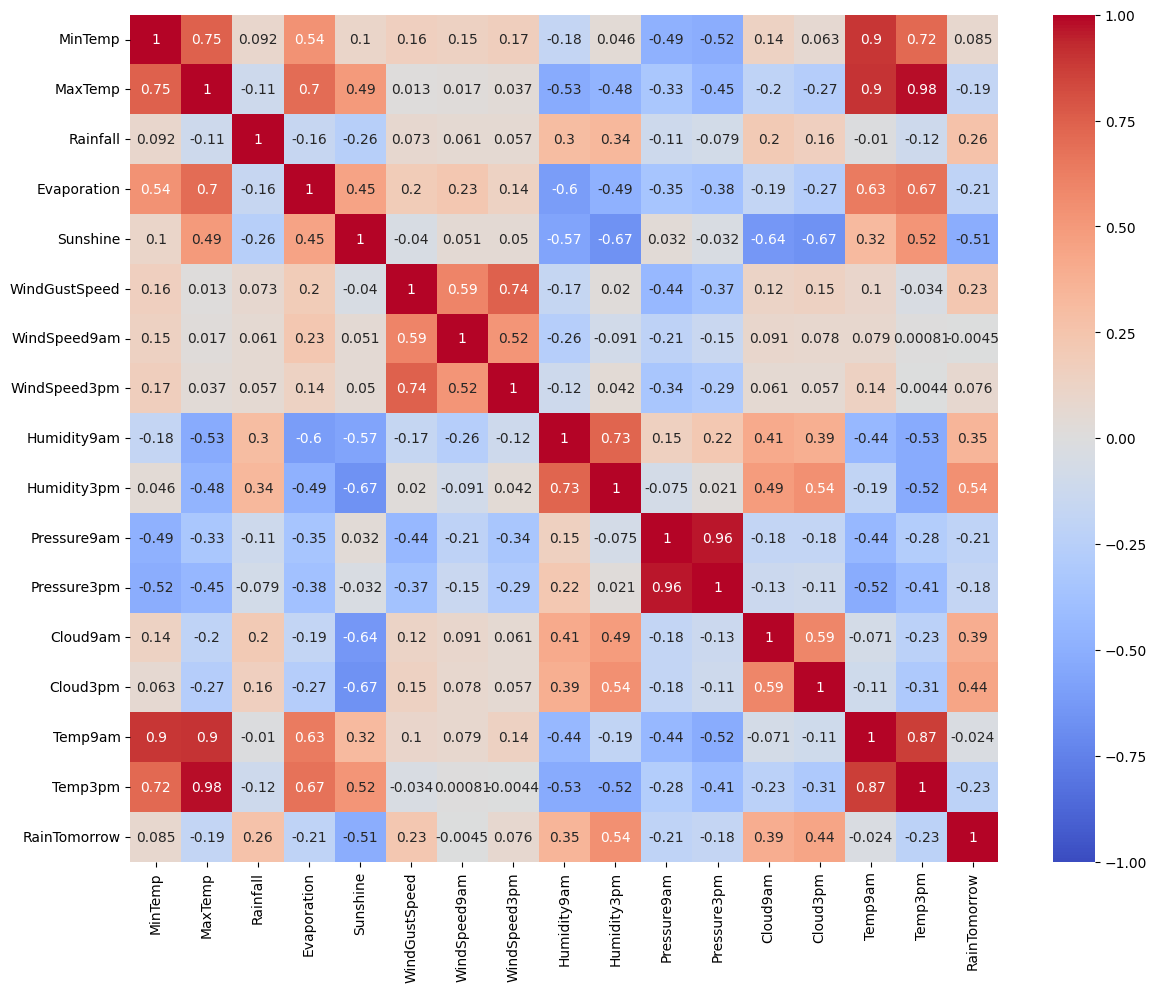

In [8]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 11))

sns.heatmap(data=corr, vmin=-1, vmax=1, cmap="coolwarm", annot=True)

## Train models

### Split the dataset into test and train

In [9]:
y = df[["RainTomorrow"]]
X = df.drop(columns=y.columns)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

### Adjust data to models

In [11]:
# MLFun supports only operations on numpy matrices
# and normalizes features by default
X_train_mlfun = X_train.to_numpy()
y_train_mlfun = y_train["RainTomorrow"].to_numpy()

X_test_mlfun = X_test.to_numpy()
y_test_mlfun = y_test["RainTomorrow"].to_numpy()

In [12]:
# Sklearn needs scaler (in this case we use StandardScaler)
# to normalize features before training and testing model
scaler = StandardScaler()

X_train_sklearn = scaler.fit_transform(X_train)
X_test_sklearn = scaler.transform(X_test)

y_train_sklearn = y_train["RainTomorrow"]
y_test_sklearn = y_test["RainTomorrow"]

### Train the models

In [13]:
%%time
scikit_model = SklearnLogisticRegression().fit(X_train_sklearn, y_train_sklearn)

CPU times: total: 15.6 ms
Wall time: 8.31 ms


In [14]:
%%time
mlfun_model = MlFunLogisticRegression().fit(X_train_mlfun, y_train_mlfun)

CPU times: total: 21.9 s
Wall time: 22 s


### Evaluate performance

In [15]:
scikit_pred = scikit_model.predict(X_test_sklearn)
root_mean_squared_error(y_test_sklearn, scikit_pred)

0.38230072737812854

In [16]:
mlfun_pred = mlfun_model.predict(X_test_mlfun)
root_mean_squared_error(y_test_mlfun, mlfun_pred)

0.3616202853397895

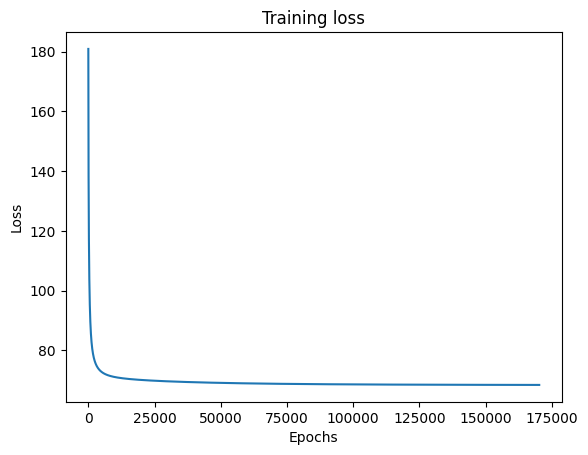

In [17]:
# This plot clearly shows the advantage of scikit's linear regression model over mine
mlfun_model.plot_losses()